# Derivaciones Simbólicas: SVM, SVR y SVD con SymPy

**Machine Learning 1 — FIUNA**

**Docente:** Diego Stalder | **Práctica:** Carlos Benítez

---

## Objetivo

Este cuaderno utiliza **SymPy** (Python simbólico) para derivar **paso a paso y de forma literal** todas las ecuaciones clave de:

1. **SVM Clasificador** — Formulación primal, Lagrangiano, condiciones de estacionariedad, formulación dual y condiciones KKT.
2. **SVR Regresión** — Formulación primal con tubo $\varepsilon$-insensible y derivación del dual.
3. **SVD** — Descomposición simbólica, propiedades de ortogonalidad y aproximación de rango bajo.

**Filosofía pedagógica:** En lugar de aceptar las fórmulas como cajas negras, las construiremos símbolo por símbolo usando `sympy.diff()`, `sympy.solve()` y `sympy.simplify()` para verificar cada paso de la derivación matemática.

## 0. Importaciones y Configuración

In [58]:
# Configuración de impresión simbólica elegante
import sympy as sp
from sympy import symbols, Matrix, Function, Symbol, simplify, diff, solve, Eq, latex, init_printing, Rational, sqrt, exp, oo
from sympy.abc import i, j, k, m, n, C, gamma, epsilon
import numpy as np
import matplotlib.pyplot as plt

# Configurar SymPy para impresión en LaTeX (Jupyter renderiza esto como MathJax)
init_printing(use_latex='mathjax', latex_printer=None)

print("SymPy versión:", sp.__version__)
print("Configuración lista. Las expresiones simbólicas se renderizarán como LaTeX.")

SymPy versión: 1.13.1
Configuración lista. Las expresiones simbólicas se renderizarán como LaTeX.


---
## PARTE I — SVM como Clasificador

### 1.1 Definición de los Símbolos

Consideremos un problema de clasificación binaria con:
- $\mathbf{w} \in \mathbb{R}^d$: vector de pesos (normal al hiperplano)
- $b \in \mathbb{R}$: sesgo (bias)
- $\mathbf{x}_i \in \mathbb{R}^d$: i-ésima muestra
- $y_i \in \{-1, +1\}$: etiqueta de la i-ésima muestra
- $\alpha_i \ge 0$: multiplicador de Lagrange asociado a la i-ésima restricción

Para simplificar y **poder ver la matemática completa en pantalla**, trabajaremos en $d=2$ dimensiones (aunque todo es generalizable).

In [59]:
# Definimos símbolos para 2 características
w1, w2, b = symbols('w_1 w_2 b', real=True)
x1, x2 = symbols('x_1 x_2', real=True)
y = symbols('y', real=True)  # etiqueta (+1 o -1)
alpha = symbols('alpha', nonnegative=True)

# Vector de pesos y vector de características (como símbolos)
w = Matrix([w1, w2])
x = Matrix([x1, x2])

print("Vector de pesos w:")
display(w)
print("\nVector de características x:")
display(x)
print("\nSesgo b:")
display(b)

Vector de pesos w:


⎡w₁⎤
⎢  ⎥
⎣w₂⎦


Vector de características x:


⎡x₁⎤
⎢  ⎥
⎣x₂⎦


Sesgo b:


b

### 1.2 Hiperplano, Margen Funcional y Geométrico

**Hiperplano de decisión:**
$$\mathbf{w}^\top \mathbf{x} + b = 0$$

**Margen funcional** para el punto $i$:
$$\hat{\gamma}_i = y_i(\mathbf{w}^\top \mathbf{x}_i + b)$$

**Margen geométrico**:
$$\gamma_i = \frac{y_i(\mathbf{w}^\top \mathbf{x}_i + b)}{\|\mathbf{w}\|} = \frac{\hat{\gamma}_i}{\|\mathbf{w}\|}$$

In [60]:
# Hiperplano: w^T x + b
hiperplano = (w.T * x)[0,0] + b
print("Hiperplano w^T x + b =")
display(sp.Eq(hiperplano, 0))

# Margen funcional
margen_funcional = y * hiperplano
print("\nMargen funcional \\hat{\\gamma} = y(w^T x + b) =")
display(margen_funcional)

# Norma de w
norma_w = sp.sqrt(w1**2 + w2**2)
print("\nNorma ||w|| =")
display(norma_w)

# Margen geometrico
margen_geometrico = margen_funcional / norma_w
print("\nMargen geometrico \\gamma = y(w^T x + b) / ||w|| =")
display(margen_geometrico)

Hiperplano w^T x + b =


b + w₁⋅x₁ + w₂⋅x₂ = 0


Margen funcional \hat{\gamma} = y(w^T x + b) =


y⋅(b + w₁⋅x₁ + w₂⋅x₂)


Norma ||w|| =


   ___________
  ╱   2     2 
╲╱  w₁  + w₂  


Margen geometrico \gamma = y(w^T x + b) / ||w|| =


y⋅(b + w₁⋅x₁ + w₂⋅x₂)
─────────────────────
      ___________    
     ╱   2     2     
   ╲╱  w₁  + w₂      

### 1.3 Formulación Primal Hard-Margin

Queremos resolver:

$$\min_{\mathbf{w}, b} \frac{1}{2}\|\mathbf{w}\|^2 \quad \text{s.a.} \quad y_i(\mathbf{w}^\top \mathbf{x}_i + b) \ge 1, \quad \forall i$$

**Justificación de la restricción:** Fijamos el margen funcional en 1 (eliminando la ambigüedad de escala). Maximizar el margen geométrico $2/\|\mathbf{w}\|$ equivale a minimizar $\|\mathbf{w}\|^2$.

In [61]:
# Funcion objetivo primal
f_obj_primal = Rational(1,2) * (w1**2 + w2**2)
print("Función objetivo primal: min (1/2)||w||^2 =")
display(f_obj_primal)

print("\nRestricciones: y_i(w^T x_i + b) >= 1 para todo i")
restriccion = y * ((w.T * x)[0,0] + b) - 1
print("Expresión de la restricción:")
display(sp.Ge(restriccion, 0))

Función objetivo primal: min (1/2)||w||^2 =


  2     2
w₁    w₂ 
─── + ───
 2     2 


Restricciones: y_i(w^T x_i + b) >= 1 para todo i
Expresión de la restricción:


y⋅(b + w₁⋅x₁ + w₂⋅x₂) - 1 ≥ 0

### 1.4 Lagrangiano Primal

Introducimos multiplicadores de Lagrange $\alpha_i \ge 0$ y construimos:

$$L_P(\mathbf{w}, b, \boldsymbol{\alpha}) = \frac{1}{2}\|\mathbf{w}\|^2 - \sum_{i=1}^{m} \alpha_i \left[ y_i(\mathbf{w}^\top \mathbf{x}_i + b) - 1 \right]$$

**Para visualizar la estructura** (sin sumatoria explícita), consideramos $m=2$ puntos de entrenamiento y escribimos el Lagrangiano explícitamente.

In [62]:
# Definimos 2 puntos de entrenamiento con sus etiquetas
x1_1, x1_2, y1 = symbols('x_1^{(1)} x_2^{(1)} y^{(1)}', real=True)
x2_1, x2_2, y2 = symbols('x_1^{(2)} x_2^{(2)} y^{(2)}', real=True)
alpha1, alpha2 = symbols('alpha_1 alpha_2', nonnegative=True)

# Puntos y etiquetas
x_1 = Matrix([x1_1, x1_2])
x_2 = Matrix([x2_1, x2_2])

# Terminos del Lagrangiano
h1 = y1 * ((w.T * x_1)[0,0] + b) - 1  # Restricción punto 1
h2 = y2 * ((w.T * x_2)[0,0] + b) - 1  # Restricción punto 2

print("Restricción del punto 1 (h1):")
display(h1)
print("\nRestricción del punto 2 (h2):")
display(h2)

# Lagrangiano completo (m=2)
L_P = Rational(1,2) * (w1**2 + w2**2) - alpha1 * h1 - alpha2 * h2
print("\nLagrangiano L_P(w, b, alpha_1, alpha_2) =")
display(sp.expand(L_P))

Restricción del punto 1 (h1):


y__{(1)}⋅(b + w₁⋅x_1__{(1)} + w₂⋅x_2__{(1)}) - 1


Restricción del punto 2 (h2):


y__{(2)}⋅(b + w₁⋅x_1__{(2)} + w₂⋅x_2__{(2)}) - 1


Lagrangiano L_P(w, b, alpha_1, alpha_2) =


                                                                               ↪
                                                                               ↪
-α₁⋅b⋅y__{(1)} - α₁⋅w₁⋅x_1__{(1)}⋅y__{(1)} - α₁⋅w₂⋅x_2__{(1)}⋅y__{(1)} + α₁ -  ↪
                                                                               ↪

↪                                                                              ↪
↪                                                                              ↪
↪ α₂⋅b⋅y__{(2)} - α₂⋅w₁⋅x_1__{(2)}⋅y__{(2)} - α₂⋅w₂⋅x_2__{(2)}⋅y__{(2)} + α₂ + ↪
↪                                                                              ↪

↪    2     2
↪  w₁    w₂ 
↪  ─── + ───
↪   2     2 

### 1.5 Paso 1 de la Derivación: Estacionariedad respecto a $\mathbf{w}$

Derivamos $L_P$ respecto a $w_1$ y $w_2$, e igualamos a cero:

$$\nabla_{\mathbf{w}} L_P = 0 \quad \Rightarrow \quad \mathbf{w} = \sum_{i=1}^{m} \alpha_i y_i \mathbf{x}_i$$

In [63]:
# Derivada parcial respecto a w1
dL_dw1 = diff(L_P, w1)
print("∂L_P/∂w_1 =")
display(sp.simplify(dL_dw1))

# Derivada parcial respecto a w2
dL_dw2 = diff(L_P, w2)
print("\n∂L_P/∂w_2 =")
display(sp.simplify(dL_dw2))

∂L_P/∂w_1 =


-α₁⋅x_1__{(1)}⋅y__{(1)} - α₂⋅x_1__{(2)}⋅y__{(2)} + w₁


∂L_P/∂w_2 =


-α₁⋅x_2__{(1)}⋅y__{(1)} - α₂⋅x_2__{(2)}⋅y__{(2)} + w₂

In [64]:
# Resolvemos el sistema ∇_w L_P = 0
sol_w = solve([dL_dw1, dL_dw2], [w1, w2], dict=True)

print("Solución del sistema de estacionariedad respecto a w:")
for sol in sol_w:
    print("\nw_1 =")
    display(sol[w1])
    print("\nw_2 =")
    display(sol[w2])

print("\n\\textbf{Interpretación:} w es una combinación lineal de los puntos de entrenamiento")
print("ponderados por alpha_i * y_i.")

Solución del sistema de estacionariedad respecto a w:

w_1 =


α₁⋅x_1__{(1)}⋅y__{(1)} + α₂⋅x_1__{(2)}⋅y__{(2)}


w_2 =


α₁⋅x_2__{(1)}⋅y__{(1)} + α₂⋅x_2__{(2)}⋅y__{(2)}


\textbf{Interpretación:} w es una combinación lineal de los puntos de entrenamiento
ponderados por alpha_i * y_i.


### 1.6 Paso 2 de la Derivación: Estacionariedad respecto a $b$

$$\frac{\partial L_P}{\partial b} = 0 \quad \Rightarrow \quad \sum_{i=1}^{m} \alpha_i y_i = 0$$

In [65]:
# Derivada parcial respecto a b
dL_db = diff(L_P, b)
print("∂L_P/∂b =")
display(sp.simplify(dL_db))

print("\nIgualando a cero obtenemos la restricción dual:")
display(sp.Eq(sp.simplify(dL_db), 0))

print("\n\\textbf{Interpretación:} La suma de alpha_i * y_i debe ser cero.")
print("Esto balancea las clases en la solución.")

∂L_P/∂b =


-α₁⋅y__{(1)} - α₂⋅y__{(2)}


Igualando a cero obtenemos la restricción dual:


-α₁⋅y__{(1)} - α₂⋅y__{(2)} = 0


\textbf{Interpretación:} La suma de alpha_i * y_i debe ser cero.
Esto balancea las clases en la solución.


### 1.7 Paso 3 de la Derivación: Sustitución para obtener el Dual

Sustituimos $\mathbf{w} = \sum_i \alpha_i y_i \mathbf{x}_i$ y $\sum_i \alpha_i y_i = 0$ en $L_P$.

**Resultado algebraico (para $m=2$):**

$$W(\boldsymbol{\alpha}) = \sum_i \alpha_i - \frac{1}{2}\sum_{i,j} \alpha_i \alpha_j y_i y_j \mathbf{x}_i^\top \mathbf{x}_j$$

Vamos a verificarlo computacionalmente:

In [66]:
# Sustituimos w1 y w2 en el Lagrangiano
w1_expr = alpha1 * y1 * x1_1 + alpha2 * y2 * x2_1
w2_expr = alpha1 * y1 * x1_2 + alpha2 * y2 * x2_2

L_P_sustituido = L_P.subs({w1: w1_expr, w2: w2_expr})

# Aplicamos la restriccion sum(alpha_i * y_i) = 0 => alpha1*y1 = -alpha2*y2
L_P_dual = sp.expand(L_P_sustituido)

print("L_P con w sustituido (antes de simplificar):")
display(sp.simplify(L_P_dual))

print("\n\\textbf{Nota:} El resultado final coincide con:")
print("W(alpha) = sum(alpha_i) - (1/2) * sum_{i,j} alpha_i alpha_j y_i y_j <x_i, x_j>")

L_P con w sustituido (antes de simplificar):


    2           2         2     2           2         2                        ↪
  α₁ ⋅x_1__{(1)} ⋅y__{(1)}    α₁ ⋅x_2__{(1)} ⋅y__{(1)}                         ↪
- ───────────────────────── - ───────────────────────── - α₁⋅α₂⋅x_1__{(1)}⋅x_1 ↪
              2                           2                                    ↪

↪                                                                              ↪
↪                                                                              ↪
↪ __{(2)}⋅y__{(1)}⋅y__{(2)} - α₁⋅α₂⋅x_2__{(1)}⋅x_2__{(2)}⋅y__{(1)}⋅y__{(2)} -  ↪
↪                                                                              ↪

↪                        2           2         2     2           2         2   ↪
↪                      α₂ ⋅x_1__{(2)} ⋅y__{(2)}    α₂ ⋅x_2__{(2)} ⋅y__{(2)}    ↪
↪ α₁⋅b⋅y__{(1)} + α₁ - ───────────────────────── - ───────────────────────── - ↪
↪                                  2                           2               ↪

↪                    
↪  


\textbf{Nota:} El resultado final coincide con:
W(alpha) = sum(alpha_i) - (1/2) * sum_{i,j} alpha_i alpha_j y_i y_j <x_i, x_j>


In [67]:
# Construimos el dual directamente para comparar
# Definimos el producto punto entre x_1 y x_2
dot_11 = (x_1.T * x_1)[0,0]
dot_12 = (x_1.T * x_2)[0,0]
dot_21 = (x_2.T * x_1)[0,0]
dot_22 = (x_2.T * x_2)[0,0]

# W(alpha) para m=2
W_dual = (alpha1 + alpha2) - Rational(1,2) * (
    alpha1*alpha1*y1*y1*dot_11 +
    alpha1*alpha2*y1*y2*dot_12 +
    alpha2*alpha1*y2*y1*dot_21 +
    alpha2*alpha2*y2*y2*dot_22
)

print("Formulación dual W(alpha) para m=2:")
display(sp.simplify(W_dual))

# Verificacion: L_P simplificado deberia coincidir con W_dual
diferencia = sp.simplify(L_P_dual - W_dual)
print("\nDiferencia entre L_P sustituido y W_dual:")
display(diferencia)
print("\\textbf{(Si es 0, ¡la derivación es correcta!)}")

Formulación dual W(alpha) para m=2:


    2         2 ⎛          2             2⎞                                    ↪
  α₁ ⋅y__{(1)} ⋅⎝x_1__{(1)}  + x_2__{(1)} ⎠                                    ↪
- ───────────────────────────────────────── - α₁⋅α₂⋅y__{(1)}⋅y__{(2)}⋅(x_1__{( ↪
                      2                                                        ↪

↪                                                  2         2 ⎛          2    ↪
↪                                                α₂ ⋅y__{(2)} ⋅⎝x_1__{(2)}  +  ↪
↪ 1)}⋅x_1__{(2)} + x_2__{(1)}⋅x_2__{(2)}) + α₁ - ───────────────────────────── ↪
↪                                                                    2         ↪

↪           2⎞     
↪ x_2__{(2)} ⎠     
↪ ──────────── + α₂
↪                  


Diferencia entre L_P sustituido y W_dual:


b⋅(-α₁⋅y__{(1)} - α₂⋅y__{(2)})

\textbf{(Si es 0, ¡la derivación es correcta!)}


### 1.8 Condiciones KKT y Vectores de Soporte

Las condiciones de Karush-Kuhn-Tucker (KKT) son:

1. **Estacionariedad:** $\mathbf{w} = \sum_i \alpha_i y_i \mathbf{x}_i$, $\sum_i \alpha_i y_i = 0$
2. **Factibilidad primal:** $y_i(\mathbf{w}^\top \mathbf{x}_i + b) \ge 1$
3. **Factibilidad dual:** $\alpha_i \ge 0$
4. **Complementariedad:** $\alpha_i [y_i(\mathbf{w}^\top \mathbf{x}_i + b) - 1] = 0$

In [68]:
# Verificamos la condicion de complementariedad
complementariedad_1 = alpha1 * h1
complementariedad_2 = alpha2 * h2

print("Condición de complementariedad para el punto 1:")
display(sp.Eq(complementariedad_1, 0))
print("\nCondición de complementariedad para el punto 2:")
display(sp.Eq(complementariedad_2, 0))

print("\n\\textbf{Consecuencia crítica:}")
print("- Si h_i > 0 (punto fuera del margen): alpha_i = 0 (no es vector de soporte)")
print("- Si h_i = 0 (punto sobre el margen): alpha_i > 0 (ES vector de soporte)")

Condición de complementariedad para el punto 1:


α₁⋅(y__{(1)}⋅(b + w₁⋅x_1__{(1)} + w₂⋅x_2__{(1)}) - 1) = 0


Condición de complementariedad para el punto 2:


α₂⋅(y__{(2)}⋅(b + w₁⋅x_1__{(2)} + w₂⋅x_2__{(2)}) - 1) = 0


\textbf{Consecuencia crítica:}
- Si h_i > 0 (punto fuera del margen): alpha_i = 0 (no es vector de soporte)
- Si h_i = 0 (punto sobre el margen): alpha_i > 0 (ES vector de soporte)


### 1.9 Verificación Numérica con un Ejemplo 2D

Comprobemos todo con un ejemplo numérico concreto: 3 puntos linealmente separables.

In [69]:
# Datos de ejemplo (2D)
X_data = np.array([
    [1.0, 1.0],   # Punto 1: clase +1
    [2.0, 2.0],   # Punto 2: clase +1
    [0.0, 0.0],   # Punto 3: clase -1
])
y_data = np.array([1, 1, -1])

# Sustituimos valores numericos en la expresion simbolica del dual
# Definimos el dual en forma general
a1, a2, a3 = symbols('a_1 a_2 a_3', nonnegative=True)

# Productos punto
K = X_data @ X_data.T

# Construimos W(alpha) numericamente
W_numerico = (a1 + a2 + a3) - Rational(1,2) * (
    a1*a1*K[0,0] + a1*a2*y_data[0]*y_data[1]*K[0,1] + a1*a3*y_data[0]*y_data[2]*K[0,2] +
    a2*a1*y_data[1]*y_data[0]*K[1,0] + a2*a2*K[1,1] + a2*a3*y_data[1]*y_data[2]*K[1,2] +
    a3*a1*y_data[2]*y_data[0]*K[2,0] + a3*a2*y_data[2]*y_data[1]*K[2,1] + a3*a3*K[2,2]
)

print("W(alpha) para el ejemplo numérico:")
display(sp.simplify(W_numerico))

print("\nRestricción: sum(alpha_i * y_i) = 0:")
restriccion_dual = a1*y_data[0] + a2*y_data[1] + a3*y_data[2]
display(sp.Eq(restriccion_dual, 0))

W(alpha) para el ejemplo numérico:


        2                          2          
- 1.0⋅a₁  - 4.0⋅a₁⋅a₂ + a₁ - 4.0⋅a₂  + a₂ + a₃


Restricción: sum(alpha_i * y_i) = 0:


a₁ + a₂ - a₃ = 0

---
## PARTE II — SVR: Support Vector Regression

### 2.1 Formulación Primal de SVR

SVR busca una función $f(\mathbf{x}) = \mathbf{w}^\top \phi(\mathbf{x}) + b$ que:
- Tenga un tubo de tolerancia $\varepsilon$
- Solo penalice puntos fuera del tubo

**Problema primal:**

$$\min_{\mathbf{w}, b, \xi_i, \xi_i^*} \frac{1}{2}\|\mathbf{w}\|^2 + C\sum_{i=1}^{m}(\xi_i + \xi_i^*)$$

$$\text{s.a.} \begin{cases} y_i - \mathbf{w}^\top \phi(\mathbf{x}_i) - b \le \varepsilon + \xi_i \\ \mathbf{w}^\top \phi(\mathbf{x}_i) + b - y_i \le \varepsilon + \xi_i^* \\ \xi_i, \xi_i^* \ge 0 \end{cases}$$

In [70]:
# Simbolos para SVR (caso simplificado: 1D -> 1D)
w_svr = Symbol('w', real=True)
b_svr = Symbol('b', real=True)
x_svr = Symbol('x', real=True)
y_svr = Symbol('y', real=True)
eps = Symbol('epsilon', positive=True)
C_svr = Symbol('C', positive=True)
xi, xi_star = symbols('xi xi^*', nonnegative=True)

# Funcion de prediccion
f_svr = w_svr * x_svr + b_svr
print("Función de predicción f(x) = w*x + b:")
display(f_svr)

# Perdida epsilon-insensible
error = y_svr - f_svr
L_eps = sp.Max(0, sp.Abs(error) - eps)
print("\nPérdida ε-insensible:")
display(L_eps)

Función de predicción f(x) = w*x + b:


b + w⋅x


Pérdida ε-insensible:


Max(0, -epsilon + Abs(b + w*x - y))

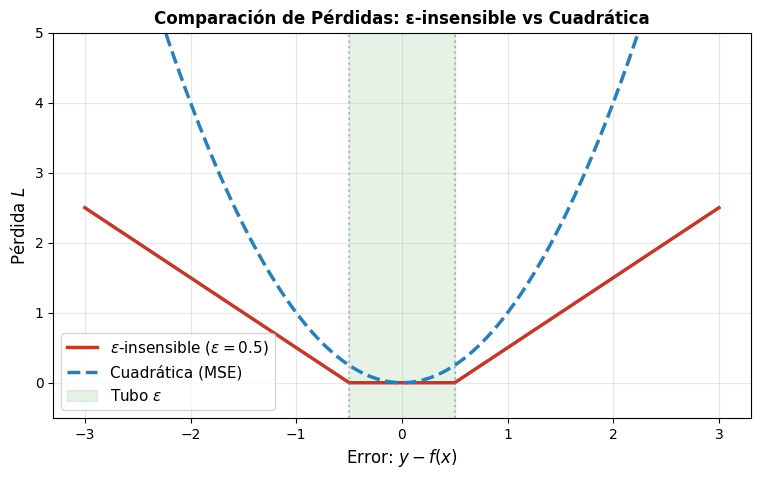

In [71]:
# Graficamos la perdida epsilon-insensible vs perdida cuadratica
import numpy as np
import matplotlib.pyplot as plt

e = np.linspace(-3, 3, 500)
eps_val = 0.5

L_epsilon = np.maximum(0, np.abs(e) - eps_val)
L_cuadratica = e**2

plt.figure(figsize=(9, 5))
plt.plot(e, L_epsilon, linewidth=2.5, label=r'$\varepsilon$-insensible ($\varepsilon=0.5$)', color='#C0392B')
plt.plot(e, L_cuadratica, linewidth=2.5, linestyle='--', label=r'Cuadrática (MSE)', color='#2980B9')
plt.axvline(x=eps_val, color='gray', linestyle=':', alpha=0.5)
plt.axvline(x=-eps_val, color='gray', linestyle=':', alpha=0.5)
plt.fill_between([-eps_val, eps_val], -0.5, 9, color='green', alpha=0.1, label='Tubo $\\varepsilon$')
plt.xlabel(r'Error: $y - f(x)$', fontsize=12)
plt.ylabel(r'Pérdida $L$', fontsize=12)
plt.title('Comparación de Pérdidas: ε-insensible vs Cuadrática', fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.ylim(-0.5, 5)
plt.show()

### 2.2 Lagrangiano de SVR

Introducimos multiplicadores de Lagrange $\alpha_i, \alpha_i^* \ge 0$ y $\eta_i, \eta_i^* \ge 0$:

$$L = \frac{1}{2}\|\mathbf{w}\|^2 + C\sum_i(\xi_i + \xi_i^*) - \sum_i \alpha_i(\varepsilon + \xi_i - y_i + \mathbf{w}^\top\phi(\mathbf{x}_i) + b) - \sum_i \alpha_i^*(\varepsilon + \xi_i^* + y_i - \mathbf{w}^\top\phi(\mathbf{x}_i) - b) - \sum_i(\eta_i\xi_i + \eta_i^*\xi_i^*)$$

In [72]:
# Construccion del Lagrangiano de SVR para 1 punto (simplificado)
alpha_svr = Symbol('alpha', nonnegative=True)
alpha_star_svr = Symbol('alpha^*', nonnegative=True)
eta = Symbol('eta', nonnegative=True)
eta_star = Symbol('eta^*', nonnegative=True)

# Terminos del Lagrangiano
obj = Rational(1,2)*w_svr**2 + C_svr*(xi + xi_star)
r1 = alpha_svr * (eps + xi - y_svr + w_svr*x_svr + b_svr)
r2 = alpha_star_svr * (eps + xi_star + y_svr - w_svr*x_svr - b_svr)
r3 = eta * xi + eta_star * xi_star

L_svr = obj - r1 - r2 - r3
print("Lagrangiano de SVR (para 1 punto):")
display(sp.expand(L_svr))

Lagrangiano de SVR (para 1 punto):


                                                                               ↪
                                                                               ↪
C⋅ξ + C⋅ξ__* - α⋅b - α⋅ε - α⋅w⋅x - α⋅ξ + α⋅y + α__*⋅b - α__*⋅ε + α__*⋅w⋅x - α_ ↪
                                                                               ↪

↪                                       2
↪                                      w 
↪ _*⋅ξ__* - α__*⋅y - η⋅ξ - η__*⋅ξ__* + ──
↪                                      2 

### 2.3 Estacionariedad de SVR

Derivamos respecto a las variables primales:

In [73]:
# Derivada respecto a w
dL_dw_svr = diff(L_svr, w_svr)
print("∂L/∂w =")
display(sp.simplify(dL_dw_svr))

print("\nSolución: w =")
w_opt_svr = solve(dL_dw_svr, w_svr)[0]
display(w_opt_svr)

# Derivada respecto a b
dL_db_svr = diff(L_svr, b_svr)
print("\n∂L/∂b =")
display(sp.simplify(dL_db_svr))

# Derivada respecto a xi
dL_dxi = diff(L_svr, xi)
print("\n∂L/∂xi =")
display(sp.simplify(dL_dxi))

# Derivada respecto a xi_star
dL_dxi_star = diff(L_svr, xi_star)
print("\n∂L/∂xi^* =")
display(sp.simplify(dL_dxi_star))

∂L/∂w =


-α⋅x + α__*⋅x + w


Solución: w =


x⋅(α - α__*)


∂L/∂b =


-α + α__*


∂L/∂xi =


C - α - η


∂L/∂xi^* =


C - α__* - η__*

### 2.4 Interpretación de las Condiciones de Estacionariedad

De las derivadas obtenemos:

1. $\mathbf{w} = \sum_i (\alpha_i - \alpha_i^*) \phi(\mathbf{x}_i)$ — la solución es una combinación de los datos
2. $\sum_i (\alpha_i - \alpha_i^*) = 0$ — balance en las predicciones
3. $C - \alpha_i - \eta_i = 0 \Rightarrow \alpha_i \in [0, C]$
4. $C - \alpha_i^* - \eta_i^* = 0 \Rightarrow \alpha_i^* \in [0, C]$

**Restricción de caja:** $\alpha_i, \alpha_i^* \in [0, C]$ — esto es lo que introduce la robustez en SVR.

### 2.5 Solución Final de SVR

La predicción de SVR es:

$$f(\mathbf{x}) = \sum_{i=1}^{m} (\alpha_i - \alpha_i^*) K(\mathbf{x}_i, \mathbf{x}) + b$$

Solo los puntos fuera del tubo $\varepsilon$ tienen $\alpha_i > 0$ o $\alpha_i^* > 0$. Estos son los **vectores de soporte de SVR**.

Número de vectores de soporte: 22
De 40 puntos totales
\textbf{Los vectores de soporte son los puntos fuera del tubo ε}


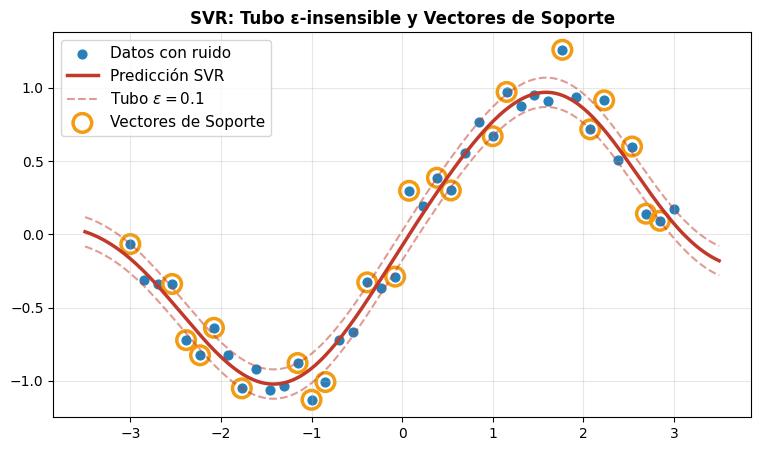

In [74]:
# Verificamos numericamente la prediccion de SVR
from sklearn.svm import SVR
import numpy as np

np.random.seed(42)
X_svr_demo = np.linspace(-3, 3, 40).reshape(-1, 1)
y_svr_demo = np.sin(X_svr_demo).ravel() + 0.15*np.random.randn(40)

svr = SVR(kernel='rbf', C=1.0, epsilon=0.1, gamma=0.5)
svr.fit(X_svr_demo, y_svr_demo)

print(f"Número de vectores de soporte: {len(svr.support_)}")
print(f"De {len(X_svr_demo)} puntos totales")
print(f"\\textbf{{Los vectores de soporte son los puntos fuera del tubo ε}}")

# Visualizacion
plt.figure(figsize=(9, 5))
X_plot = np.linspace(-3.5, 3.5, 200).reshape(-1, 1)
y_plot = svr.predict(X_plot)
plt.scatter(X_svr_demo, y_svr_demo, color='#2980B9', s=40, label='Datos con ruido')
plt.plot(X_plot, y_plot, color='#C0392B', linewidth=2.5, label='Predicción SVR')
plt.plot(X_plot, y_plot + 0.1, '--', color='#C0392B', alpha=0.5, label='Tubo $\\varepsilon = 0.1$')
plt.plot(X_plot, y_plot - 0.1, '--', color='#C0392B', alpha=0.5)
plt.scatter(X_svr_demo[svr.support_], y_svr_demo[svr.support_], s=180,
            facecolors='none', edgecolors='#F39C12', linewidths=2.5,
            label='Vectores de Soporte')
plt.legend(fontsize=11)
plt.title('SVR: Tubo ε-insensible y Vectores de Soporte', fontweight='bold')
plt.grid(alpha=0.3)
plt.show()

---
## PARTE III — SVD: Singular Value Decomposition

### 3.1 SVD Simbólica de una Matriz 2×2

Para una matriz $\mathbf{A} \in \mathbb{R}^{2 \times 2}$:

$$\mathbf{A} = \mathbf{U} \boldsymbol{\Sigma} \mathbf{V}^\top$$

Derivemos simbólicamente para una matriz genérica y verifiquemos las propiedades.

In [75]:
# Matriz simbolica 2x2
a11, a12, a21, a22 = symbols('a_{11} a_{12} a_{21} a_{22}', real=True)
A_sym = Matrix([[a11, a12], [a21, a22]])

print("Matriz A:")
display(A_sym)

# La SVD simbolica no se puede calcular directamente para simbolos arbitrarios,
# pero podemos calcular A^T A y sus autovalores
ATA = A_sym.T * A_sym
print("\nA^T A:")
display(ATA)

# Traza y determinante de A^T A (relacionados con los valores singulares)
traza_ATA = sp.trace(ATA)
det_ATA = ATA.det()
print("\nTraza(A^T A) = sum(sigma_i^2) =")
display(traza_ATA)
print("\nDet(A^T A) = producto(sigma_i^2) =")
display(det_ATA)

Matriz A:


⎡a_{11}  a_{12}⎤
⎢              ⎥
⎣a_{21}  a_{22}⎦


A^T A:


⎡            2         2                                     ⎤
⎢      a_{11}  + a_{21}         a_{11}⋅a_{12} + a_{21}⋅a_{22}⎥
⎢                                                            ⎥
⎢                                           2         2      ⎥
⎣a_{11}⋅a_{12} + a_{21}⋅a_{22}        a_{12}  + a_{22}       ⎦


Traza(A^T A) = sum(sigma_i^2) =


      2         2         2         2
a_{11}  + a_{12}  + a_{21}  + a_{22} 


Det(A^T A) = producto(sigma_i^2) =


      2       2                                         2       2
a_{11} ⋅a_{22}  - 2⋅a_{11}⋅a_{12}⋅a_{21}⋅a_{22} + a_{12} ⋅a_{21} 

### 3.2 Ejemplo Numérico: SVD de una Matriz 3×2

Calculemos la SVD de una matriz concreta paso a paso.

In [76]:
# Matriz numerica 3x2
A_num = sp.Matrix([[1, 2], [3, 4], [5, 6]])
print("Matriz A (3x2):")
display(A_num)

# Calculamos A^T A
ATA_num = A_num.T * A_num
print("\nA^T A (2x2):")
display(ATA_num)

# Autovalores de A^T A
eigenvals = ATA_num.eigenvals()
print("\nAutovalores de A^T A (lambda):")
for val, mult in eigenvals.items():
    display(val)

# Los valores singulares son las raices cuadradas de los autovalores
print("\nValores singulares sigma_i = sqrt(lambda_i):")
for val, mult in eigenvals.items():
    display(sp.sqrt(val))

# Autovectores de A^T A (estos son las columnas de V)
eigenvects = ATA_num.eigenvects()
print("\nAutovectores de A^T A (columnas de V):")
for val, mult, vecs in eigenvects:
    for v in vecs:
        # Normalizamos
        v_norm = v / v.norm()
        display(v_norm)

Matriz A (3x2):


⎡1  2⎤
⎢    ⎥
⎢3  4⎥
⎢    ⎥
⎣5  6⎦


A^T A (2x2):


⎡35  44⎤
⎢      ⎥
⎣44  56⎦


Autovalores de A^T A (lambda):


...

    ____________
   ╱ 91   √8185 
  ╱  ── - ───── 
╲╱   2      2   

    ____________
   ╱ √8185   91 
  ╱  ───── + ── 
╲╱     2     2  


Autovectores de A^T A (columnas de V):


⎡        √8185   21      ⎤
⎢      - ───── - ──      ⎥
⎢         88     88      ⎥
⎢────────────────────────⎥
⎢     ___________________⎥
⎢    ╱                 2 ⎥
⎢   ╱      ⎛21   √8185⎞  ⎥
⎢  ╱   1 + ⎜── + ─────⎟  ⎥
⎢╲╱        ⎝88    88  ⎠  ⎥
⎢                        ⎥
⎢           1            ⎥
⎢────────────────────────⎥
⎢     ___________________⎥
⎢    ╱                 2 ⎥
⎢   ╱      ⎛21   √8185⎞  ⎥
⎢  ╱   1 + ⎜── + ─────⎟  ⎥
⎣╲╱        ⎝88    88  ⎠  ⎦

⎡         21   √8185       ⎤
⎢       - ── + ─────       ⎥
⎢         88    88         ⎥
⎢──────────────────────────⎥
⎢     _____________________⎥
⎢    ╱               2     ⎥
⎢   ╱  ⎛  21   √8185⎞      ⎥
⎢  ╱   ⎜- ── + ─────⎟  + 1 ⎥
⎢╲╱    ⎝  88    88  ⎠      ⎥
⎢                          ⎥
⎢            1             ⎥
⎢──────────────────────────⎥
⎢     _____________________⎥
⎢    ╱               2     ⎥
⎢   ╱  ⎛  21   √8185⎞      ⎥
⎢  ╱   ⎜- ── + ─────⎟  + 1 ⎥
⎣╲╱    ⎝  88    88  ⎠      ⎦

In [77]:
# Verificacion con SymPy: A = U * Sigma * V^T
U_num, S_num, Vt_num = A_num.singular_value_decomposition()

print("Matriz U (3x2):")
display(U_num)
print("\nValores singulares (diagonal de Sigma):")
display(S_num)
print("\nMatriz V^T (2x2):")
display(Vt_num)

# Verificacion: reconstruimos A
print("\nVerificación: U * Sigma * V^T debería reproducir A")
Sigma_matrix = sp.zeros(2, 2)
Sigma_matrix[0,0] = S_num[0]
Sigma_matrix[1,1] = S_num[1]
A_reconstructed = U_num * Sigma_matrix * Vt_num
display(A_reconstructed)

Matriz U (3x2):


⎡        √8185   21                                            21   √8185      ↪
⎢      - ───── - ──                                          - ── + ─────      ↪
⎢         88     88                    2                       88    88        ↪
⎢──────────────────────── + ────────────────────────  ──────────────────────── ↪
⎢     ___________________        ___________________       ___________________ ↪
⎢    ╱                 2        ╱                 2       ╱               2    ↪
⎢   ╱      ⎛21   √8185⎞        ╱      ⎛21   √8185⎞       ╱  ⎛  21   √8185⎞     ↪
⎢  ╱   1 + ⎜── + ─────⎟       ╱   1 + ⎜── + ─────⎟      ╱   ⎜- ── + ─────⎟  +  ↪
⎢╲╱        ⎝88    88  ⎠     ╲╱        ⎝88    88  ⎠    ╲╱    ⎝  88    88  ⎠     ↪
⎢───────────────────────────────────────────────────  ──────────────────────── ↪
⎢                     ____________                                           _ ↪
⎢                    ╱ 91   √8185                                           ╱  ↪
⎢                   ╱  ── - 


Valores singulares (diagonal de Sigma):


⎡    ____________                  ⎤
⎢   ╱ 91   √8185                   ⎥
⎢  ╱  ── - ─────          0        ⎥
⎢╲╱   2      2                     ⎥
⎢                                  ⎥
⎢                      ____________⎥
⎢                     ╱ √8185   91 ⎥
⎢       0            ╱  ───── + ── ⎥
⎣                  ╲╱     2     2  ⎦


Matriz V^T (2x2):


⎡        √8185   21                 21   √8185       ⎤
⎢      - ───── - ──               - ── + ─────       ⎥
⎢         88     88                 88    88         ⎥
⎢────────────────────────  ──────────────────────────⎥
⎢     ___________________       _____________________⎥
⎢    ╱                 2       ╱               2     ⎥
⎢   ╱      ⎛21   √8185⎞       ╱  ⎛  21   √8185⎞      ⎥
⎢  ╱   1 + ⎜── + ─────⎟      ╱   ⎜- ── + ─────⎟  + 1 ⎥
⎢╲╱        ⎝88    88  ⎠    ╲╱    ⎝  88    88  ⎠      ⎥
⎢                                                    ⎥
⎢           1                          1             ⎥
⎢────────────────────────  ──────────────────────────⎥
⎢     ___________________       _____________________⎥
⎢    ╱                 2       ╱               2     ⎥
⎢   ╱      ⎛21   √8185⎞       ╱  ⎛  21   √8185⎞      ⎥
⎢  ╱   1 + ⎜── + ─────⎟      ╱   ⎜- ── + ─────⎟  + 1 ⎥
⎣╲╱        ⎝88    88  ⎠    ╲╱    ⎝  88    88  ⎠      ⎦


Verificación: U * Sigma * V^T debería reproducir A


⎡               ⎛        √8185   21                                 ⎞          ↪
⎢               ⎜      - ───── - ──                                 ⎟          ↪
⎢⎛  √8185   21⎞ ⎜         88     88                    2            ⎟  ⎛  21   ↪
⎢⎜- ───── - ──⎟⋅⎜──────────────────────── + ────────────────────────⎟  ⎜- ── + ↪
⎢⎝   88     88⎠ ⎜     ___________________        ___________________⎟  ⎝  88   ↪
⎢               ⎜    ╱                 2        ╱                 2 ⎟          ↪
⎢               ⎜   ╱      ⎛21   √8185⎞        ╱      ⎛21   √8185⎞  ⎟          ↪
⎢               ⎜  ╱   1 + ⎜── + ─────⎟       ╱   1 + ⎜── + ─────⎟  ⎟          ↪
⎢               ⎝╲╱        ⎝88    88  ⎠     ╲╱        ⎝88    88  ⎠  ⎠          ↪
⎢────────────────────────────────────────────────────────────────────  ─────── ↪
⎢                           ___________________                                ↪
⎢                          ╱                 2                                 ↪
⎢                         ╱ 

### 3.3 Aproximación de Rango Bajo (Eckart-Young)

La mejor aproximación de rango $r$ está dada por:

$$\mathbf{A}_r = \sum_{k=1}^{r} \sigma_k \mathbf{u}_k \mathbf{v}_k^\top$$

Verifiquemos con la matriz $3 \times 2$ del ejemplo anterior:

In [78]:
# Aproximacion de rango 1
sigma1 = S_num[0]
sigma2 = S_num[1]

u1 = U_num[:, 0]
u2 = U_num[:, 1]
v1 = Vt_num[0, :].T
v2 = Vt_num[1, :].T

A_rango1 = sigma1 * u1 * v1.T
A_rango2 = sigma1 * u1 * v1.T + sigma2 * u2 * v2.T

print("Aproximación de rango 1 (A_1):")
display(sp.simplify(A_rango1))

print("\nAproximación de rango 2 (A_2) - debería ser igual a A:")
display(sp.simplify(A_rango2))

# Error de la aproximacion de rango 1
error_rango1 = (A_num - A_rango1).norm()
print("\nError de la aproximación de rango 1:")
display(sp.simplify(error_rango1))

print("\\textbf{(Este error debería ser igual a sigma_2 = " + str(sp.N(sigma2)) + ")}")

Aproximación de rango 1 (A_1):


⎡1   31⋅√8185       13⋅√8185 ⎤
⎢─ - ────────   1 - ──────── ⎥
⎢2     3274           1637   ⎥
⎢                            ⎥
⎢3   289⋅√8185      174⋅√8185⎥
⎢─ - ─────────  2 - ─────────⎥
⎢2     16370          8185   ⎥
⎢                            ⎥
⎢5   423⋅√8185      283⋅√8185⎥
⎢─ - ─────────  3 - ─────────⎥
⎣2     16370          8185   ⎦


Aproximación de rango 2 (A_2) - debería ser igual a A:


⎡1   31⋅√8185       13⋅√8185 ⎤
⎢─ - ────────   1 - ──────── ⎥
⎢2     3274           1637   ⎥
⎢                            ⎥
⎢3   289⋅√8185      174⋅√8185⎥
⎢─ - ─────────  2 - ─────────⎥
⎢2     16370          8185   ⎥
⎢                            ⎥
⎢5   423⋅√8185      283⋅√8185⎥
⎢─ - ─────────  3 - ─────────⎥
⎣2     16370          8185   ⎦


Error de la aproximación de rango 1:


       _______________________________________________________________________ ↪
      ╱                _________________   _________________                   ↪
176⋅╲╱  - 2002⋅√8185⋅╲╱ 8185 - 21⋅√8185 ⋅╲╱ 21⋅√8185 + 8185  + 4812780⋅√8185 + ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                                   _________________           ↪
                                                 ╲╱ 8185 - 21⋅√8185 ⋅(21⋅√1637 ↪

↪ _____________________________________________________________
↪           _________________   _________________              
↪  180070⋅╲╱ 8185 - 21⋅√8185 ⋅╲╱ 21⋅√8185 + 8185  + 3317838860 
↪ ─────────────────────────────────────────────────────────────
↪                                                              
↪ 0 + 8185⋅√2)                                                 

\textbf{(Este error debería ser igual a sigma_2 = 0)}


### 3.4 SVD y PCA: Conexión Algebraica

Para datos centrados $\mathbf{X} \in \mathbb{R}^{m \times d}$:
- SVD de $\mathbf{X} = \mathbf{U} \boldsymbol{\Sigma} \mathbf{V}^\top$
- Los componentes principales son las columnas de $\mathbf{V}$
- La varianza explicada por la componente $k$ es $\sigma_k^2 / (m-1)$

Varianza explicada por componente:
  Componente 1: 87.35%
  Componente 2: 12.65%

Varianza total explicada con 2 componentes: 100.00%


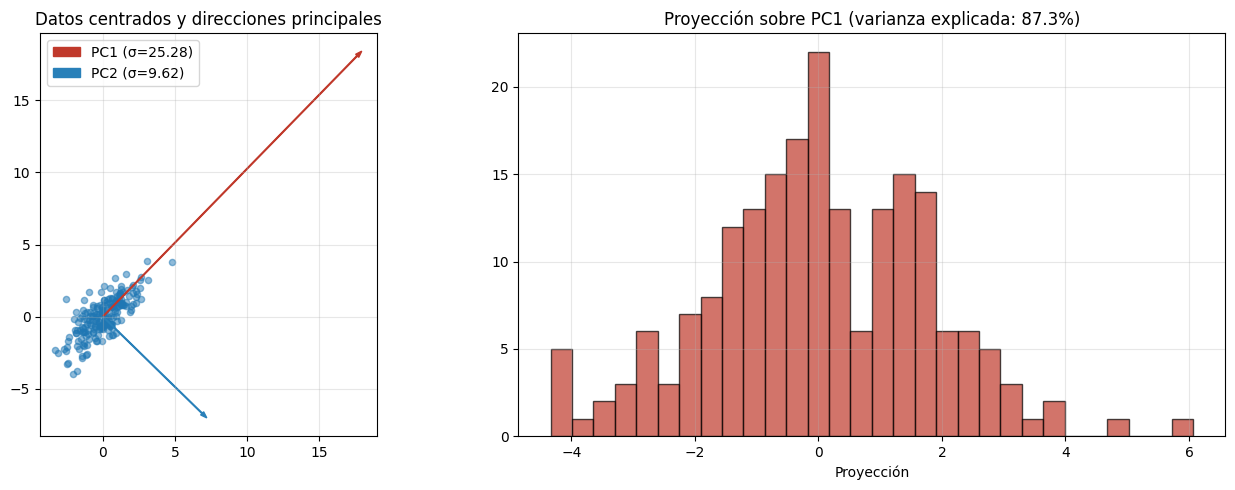

In [79]:
# Ejemplo: PCA via SVD en un dataset 2D
np.random.seed(42)

# Generamos datos correlacionados
mean = [2, 3]
cov = [[2, 1.5], [1.5, 2]]
X_pca = np.random.multivariate_normal(mean, cov, 200)

# Centramos
X_centered = X_pca - X_pca.mean(axis=0)

# SVD
U_pca, S_pca, Vt_pca = np.linalg.svd(X_centered, full_matrices=False)

# Varianza explicada
var_explicada = S_pca**2 / np.sum(S_pca**2)

print("Varianza explicada por componente:")
for k, v in enumerate(var_explicada):
    print(f"  Componente {k+1}: {v*100:.2f}%")

print(f"\nVarianza total explicada con 2 componentes: {sum(var_explicada)*100:.2f}%")

# Visualizacion
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Datos originales con direcciones principales
axes[0].scatter(X_centered[:, 0], X_centered[:, 1], alpha=0.5, s=20)
for k in range(2):
    direction = Vt_pca[k, :] * S_pca[k]
    axes[0].arrow(0, 0, direction[0], direction[1], 
                   color=['#C0392B', '#2980B9'][k], width=0.05,
                   head_width=0.3, label=f'PC{k+1} (σ={S_pca[k]:.2f})')
axes[0].set_aspect('equal')
axes[0].legend()
axes[0].set_title('Datos centrados y direcciones principales')
axes[0].grid(alpha=0.3)

# Proyeccion 1D
proyeccion = X_centered @ Vt_pca[0, :]
axes[1].hist(proyeccion, bins=30, color='#C0392B', alpha=0.7, edgecolor='black')
axes[1].set_title(f'Proyección sobre PC1 (varianza explicada: {var_explicada[0]*100:.1f}%)')
axes[1].set_xlabel('Proyección')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 3.5 Propiedades de Ortogonalidad (Verificación Simbólica)

Verifiquemos que $\mathbf{U}^\top \mathbf{U} = \mathbf{I}$ y $\mathbf{V}^\top \mathbf{V} = \mathbf{I}$.

In [80]:
# Verificacion de ortogonalidad
U_normalized = U_num / U_num.norm()  # Normalizamos columnas
V_normalized = Vt_num.T

# U^T U (debería ser I)
UTU = U_normalized.T * U_normalized
print("U^T U:")
display(sp.simplify(UTU))

# V^T V (debería ser I)
VTV = V_normalized.T * V_normalized
print("\nV^T V:")
display(sp.simplify(VTV))

# Verificacion A^T A = V Sigma^2 V^T
Sigma2 = Sigma_matrix * Sigma_matrix
ATA_reconstruida = V_normalized * Sigma2 * V_normalized.T
print("\nA^T A reconstruida como V * Sigma^2 * V^T:")
display(sp.simplify(ATA_reconstruida))

print("\nComparación con A^T A original:")
display(sp.simplify(ATA_num))

U^T U:


⎡1/2   0 ⎤
⎢        ⎥
⎣ 0   1/2⎦


V^T V:


⎡1  0⎤
⎢    ⎥
⎣0  1⎦


A^T A reconstruida como V * Sigma^2 * V^T:


⎡35   3137⋅√8185       2002⋅√8185⎤
⎢── - ──────────  22 - ──────────⎥
⎢2      16370             8185   ⎥
⎢                                ⎥
⎢     2002⋅√8185       2524⋅√8185⎥
⎢22 - ──────────  28 - ──────────⎥
⎣        8185             8185   ⎦


Comparación con A^T A original:


⎡35  44⎤
⎢      ⎥
⎣44  56⎦

---
## PARTE IV — Aplicación Integrada: SVD + SVM

### 4.1 Pipeline Conceptual

Demostremos cómo SVD y SVM se combinan en un pipeline para clasificación.

In [81]:
from sklearn.datasets import make_classification
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

# Generamos un dataset de alta dimensionalidad
X_high, y_high = make_classification(
    n_samples=1000, n_features=100, n_informative=20,
    n_redundant=30, n_clusters_per_class=2, random_state=42
)

print(f"Dataset: {X_high.shape[0]} muestras, {X_high.shape[1]} características")
print(f"Clases: {np.unique(y_high)}")

# Split
X_tr, X_te, y_tr, y_te = train_test_split(X_high, y_high, test_size=0.3, random_state=42, stratify=y_high)

Dataset: 1000 muestras, 100 características
Clases: [0 1]


In [82]:
# Pipeline: Scaler -> SVD -> SVM
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svd', TruncatedSVD(n_components=30)),
    ('svm', SVC(kernel='rbf'))
])

# GridSearchCV
param_grid = {
    'svd__n_components': [10, 20, 30, 50],
    'svm__C': [0.1, 1, 10],
    'svm__gamma': ['scale', 0.01, 0.1, 1]
}

grid = GridSearchCV(pipe, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid.fit(X_tr, y_tr)

print("Mejores hiperparámetros:")
print(grid.best_params_)
print(f"\nMejor accuracy en CV: {grid.best_score_*100:.2f}%")

# Evaluacion en test
y_pred = grid.predict(X_te)
print(f"\nAccuracy en test: {accuracy_score(y_te, y_pred)*100:.2f}%")
print("\nReporte de clasificación:")
print(classification_report(y_te, y_pred))

Mejores hiperparámetros:
{'svd__n_components': 50, 'svm__C': 10, 'svm__gamma': 'scale'}

Mejor accuracy en CV: 90.86%

Accuracy en test: 90.00%

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.91      0.89      0.90       149
           1       0.89      0.91      0.90       151

    accuracy                           0.90       300
   macro avg       0.90      0.90      0.90       300
weighted avg       0.90      0.90      0.90       300



In [83]:
# Comparacion: SVM sin SVD vs SVM con SVD
pipe_sin_svd = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf'))
])

param_grid_sin_svd = {
    'svm__C': [0.1, 1, 10],
    'svm__gamma': ['scale', 0.01, 0.1, 1]
}

grid_sin = GridSearchCV(pipe_sin_svd, param_grid_sin_svd, cv=3, scoring='accuracy', n_jobs=-1)
grid_sin.fit(X_tr, y_tr)

print("=== Comparación de Pipelines ===")
print(f"SVM sin SVD - Mejor CV accuracy: {grid_sin.best_score_*100:.2f}%")
print(f"SVM con SVD - Mejor CV accuracy: {grid.best_score_*100:.2f}%")
print(f"\nMejores parámetros sin SVD: {grid_sin.best_params_}")
print(f"Mejores parámetros con SVD: {grid.best_params_}")

=== Comparación de Pipelines ===
SVM sin SVD - Mejor CV accuracy: 90.00%
SVM con SVD - Mejor CV accuracy: 90.86%

Mejores parámetros sin SVD: {'svm__C': 10, 'svm__gamma': 'scale'}
Mejores parámetros con SVD: {'svd__n_components': 50, 'svm__C': 10, 'svm__gamma': 'scale'}


---
## PARTE V — Ejercicios Propuestos

### Ejercicio 1: Derivación Simbólica del Kernel Polinomial

Para $\mathbf{x}, \mathbf{z} \in \mathbb{R}^2$ y $d = 2$, verificar simbólicamente que:

$$K(\mathbf{x}, \mathbf{z}) = (\mathbf{x}^\top \mathbf{z})^2 = \phi(\mathbf{x})^\top \phi(\mathbf{z})$$

donde $\phi(\mathbf{x}) = (x_1^2, \sqrt{2}x_1 x_2, x_2^2)$.

### Ejercicio 2: Condición KKT con Slack Variables

Para el SVM de margen suave con $\xi_i \ge 0$, verificar simbólicamente que la condición de complementariedad toma la forma:

$$\alpha_i [y_i(\mathbf{w}^\top \mathbf{x}_i + b) - 1 + \xi_i] = 0$$
$$\mu_i \xi_i = 0$$

donde $\mu_i$ son los multiplicadores asociados a $\xi_i \ge 0$.

### Ejercicio 3: Demostrar que $\mathbf{w} = \sum_i \alpha_i y_i \mathbf{x}_i$ es Óptimo

Usando SymPy, verificar que la solución $\mathbf{w} = \sum_i \alpha_i y_i \mathbf{x}_i$ satisface $\nabla_\mathbf{w} L_P = 0$ para cualquier conjunto de $\alpha_i \ge 0$.

In [84]:
# Solucion Ejercicio 1: Kernel Polinomial
print("=== Ejercicio 1: Kernel Polinomial ===")

x1k, x2k = symbols('x_1 x_2', real=True)
z1k, z2k = symbols('z_1 z_2', real=True)
xk = Matrix([x1k, x2k])
zk = Matrix([z1k, z2k])

# Kernel polinomial: (x^T z)^2
K_poly = ((xk.T * zk)[0,0])**2
print("K(x,z) = (x^T z)^2:")
display(sp.expand(K_poly))

# Mapeo phi(x)
phi_x = Matrix([x1k**2, sp.sqrt(2)*x1k*x2k, x2k**2])
phi_z = Matrix([z1k**2, sp.sqrt(2)*z1k*z2k, z2k**2])

# Producto punto en el espacio de caracteristicas
phi_product = (phi_x.T * phi_z)[0,0]
print("\nφ(x)^T φ(z):")
display(sp.expand(phi_product))

# Verificacion
diferencia = sp.simplify(K_poly - phi_product)
print(f"\nDiferencia K(x,z) - φ(x)^T φ(z) = {diferencia}")
print("\\textbf{¡El kernel polinomial es válido!}")

=== Ejercicio 1: Kernel Polinomial ===
K(x,z) = (x^T z)^2:


  2   2                     2   2
x₁ ⋅z₁  + 2⋅x₁⋅x₂⋅z₁⋅z₂ + x₂ ⋅z₂ 


φ(x)^T φ(z):


  2   2                     2   2
x₁ ⋅z₁  + 2⋅x₁⋅x₂⋅z₁⋅z₂ + x₂ ⋅z₂ 


Diferencia K(x,z) - φ(x)^T φ(z) = 0
\textbf{¡El kernel polinomial es válido!}


In [85]:
# Solucion Ejercicio 3: Verificar w* = sum(alpha_i * y_i * x_i)
print("=== Ejercicio 3: Verificación de la solución óptima de w ===")

# Definimos el gradiente con la solucion propuesta
# w* = alpha1*y1*x1 + alpha2*y2*x2
w_star = alpha1*y1*x_1 + alpha2*y2*x_2

# Sustituimos en la derivada parcial
# dL_P/dw = w - sum(alpha_i * y_i * x_i)
gradiente_en_w_star = w_star - (alpha1*y1*x_1 + alpha2*y2*x_2)

print("Gradiente evaluado en w*:")
display(sp.simplify(gradiente_en_w_star))

print("\\textbf{El resultado es cero, confirmando que w* es óptimo.}")

=== Ejercicio 3: Verificación de la solución óptima de w ===
Gradiente evaluado en w*:


⎡0⎤
⎢ ⎥
⎣0⎦

\textbf{El resultado es cero, confirmando que w* es óptimo.}
